CSV TO DATAFRAME


In [11]:
import pandas as pd


df = pd.read_csv("data/similarityRelatedFeatures.csv")

print(df.head())
print(df.columns)
print(df.shape)
print(df.info())
print("Categories:", df["category"].nunique())
    

           category     brand                           price  \
0  wireless earbuds    Fhumsh  $19.97 with 92 percent savings   
1  wireless earbuds    Fhumsh  $19.97 with 92 percent savings   
2  wireless earbuds  XIAOWTEK  $19.99 with 90 percent savings   
3  wireless earbuds    TRAUSI  $20.99 with 92 percent savings   
4  wireless earbuds  HAOYUYAN  $23.98 with 92 percent savings   

                                         description  \
0  About this itemSmart LED Display & 50H Sport H...   
1  About this itemErgonomic Wireless Earbuds for ...   
2  About this itemLED Power Display and 50H Playb...   
3  About this item【Instant Pairing & Seamless Con...   
4  About this item【Sports Comfort & IPX7 Waterpro...   

                                               title  
0  Wireless Earbuds, Bluetooth 5.3 Headphones HiF...  
1  Wireless Earbuds, Bluetooth 5.3 Headphones HiF...  
2  XIAOWTEK Wireless Earbuds, 2026 Bluetooth 5.4 ...  
3  Wireless Earbuds Bluetooth Headphones, 54H Pla...

Data Cleaning


In [12]:

df["description"] = df["description"].fillna("")

df["price"] = (
    df["price"]
    .str.extract(r"\$([\d,]+(?:\.\d+)?)")[0]
    .str.replace(",", "", regex=False)
    .astype(float)
)



df.info()

<class 'pandas.DataFrame'>
RangeIndex: 832 entries, 0 to 831
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   category     832 non-null    str    
 1   brand        671 non-null    str    
 2   price        708 non-null    float64
 3   description  832 non-null    str    
 4   title        832 non-null    str    
dtypes: float64(1), str(4)
memory usage: 32.6 KB


In [13]:
print("Brands:", df["brand"].nunique())
print("Categories:", df["category"].nunique())

Brands: 295
Categories: 28


In [14]:
df.groupby("category")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
DSLR camera,11.0,357.808182,214.444197,79.99,219.9900,287.990,514.0000,756.96
USB-C hub,13.0,25.019231,12.944249,7.98,16.9900,19.990,39.9600,44.95
air purifier,4.0,96.365000,65.224452,22.49,65.6150,91.490,122.2400,179.99
backpack,14.0,38.297857,26.217330,13.99,26.9900,29.990,36.8725,94.99
bluetooth speaker,12.0,87.009167,112.175796,9.99,18.4900,30.990,85.6525,329.99
budget laptop,10.0,273.533000,120.136082,79.99,224.9500,245.745,314.7400,544.99
candle,42.0,27.856667,20.848026,9.99,17.2300,19.990,25.9900,119.98
coffee maker,35.0,97.651429,111.153681,21.99,42.4900,74.950,99.9900,555.95
desk lamp LED,47.0,31.354043,17.749009,9.99,19.9900,25.490,41.4700,79.99


In [15]:
df.groupby("category")["price"].transform(
    lambda x: pd.qcut(
        x,
        q=3,
        labels=["Low Budget", "Mid Budget", "High Budget"]
    )
)

0       Low Budget
1       Low Budget
2       Mid Budget
3       Mid Budget
4      High Budget
          ...     
827     Low Budget
828            NaN
829     Low Budget
830     Low Budget
831     Low Budget
Name: price, Length: 832, dtype: category
Categories (3, str): ['Low Budget' < 'Mid Budget' < 'High Budget']

EXPLORATORY DATA ANALYSIS


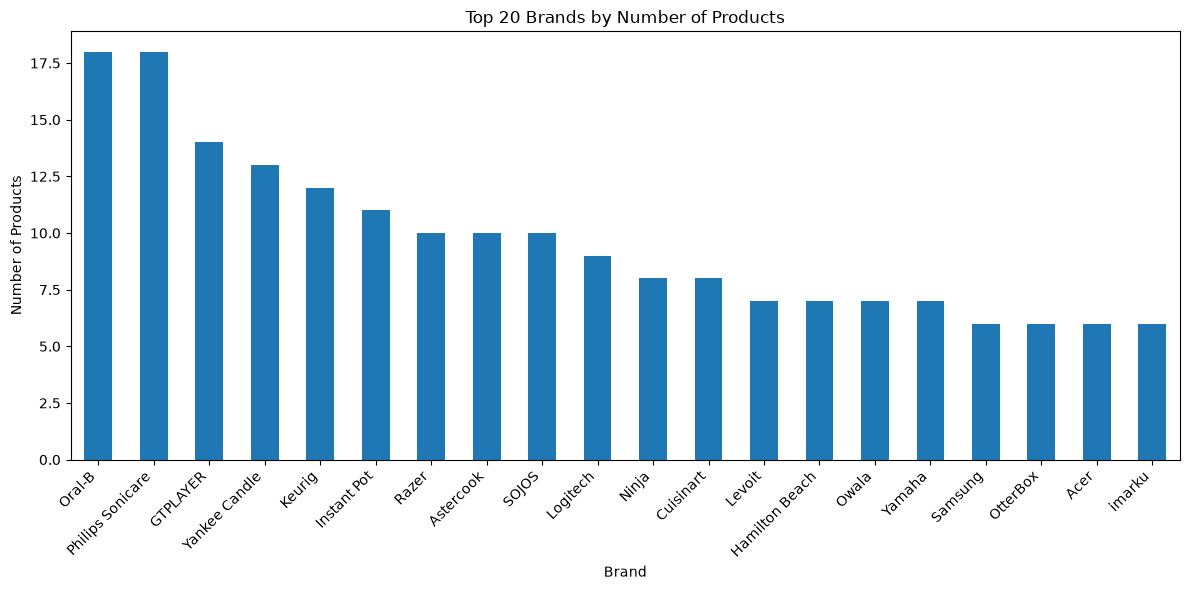

In [16]:
import matplotlib.pyplot as plt

brand_counts = df["brand"].value_counts().head(20)

brand_counts.plot(kind="bar", figsize=(12, 6))

plt.title("Top 20 Brands by Number of Products")
plt.xlabel("Brand")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()